# Notebook 30: M5 Single-Product LSTM Evaluation

This notebook recreates and adapts the original Notebook 30 for a single **M5** product experiment aligned with the AUREX workflow.

**Target product**
- Requested label: `FOODS_3_228_CA_1_val`
- Canonical M5 series id used in code: `FOODS_3_228_CA_1_validation`

**Experiment goals**
- inspect one product's demand behavior
- build a consistent train/test split
- train the repository LSTM model
- forecast the test window
- plot real vs predicted demand
- compute point and behavioral forecast metrics
- export artifacts that can later be inserted into the ACCESS LaTeX manuscript

## What Was Reused and What Was Modified

**Reused from the repository**
- `src.data_loaders.load_m5.load_m5_single_series`
- `src.models.advanced_deep_forecast_models.LSTMForecastModel`
- `src.models.deep_challenger_models.train_test_split_series`
- `src.metrics.behavioral_metrics.behavioral_metrics`

**Modified relative to the original Notebook 30**
- switched from AUREX CSV/DB loading to a fixed M5 product loader
- fixed the experiment to one canonical M5 series id
- used the repo helper split logic with `test_days=365` to stay consistent with the existing deep-model benchmark setup
- added product statistics, a full-series behavior plot, and an explicit flat-prediction flag based on variance ratio

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_loaders.load_m5 import load_m5_single_series
from src.metrics.behavioral_metrics import behavioral_metrics
from src.models.advanced_deep_forecast_models import LSTMForecastModel
from src.models.deep_challenger_models import train_test_split_series

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

In [2]:
CONFIG = {
    'SERIES_ID': 'FOODS_3_228_CA_1_validation',
    'SERIES_ALIAS': 'FOODS_3_228_CA_1_val',
    'M5_BASE_PATH': ROOT / 'data' / 'raw' / 'm5',
    'TEST_DAYS': 365,
    'CONTEXT_LENGTH': 28,
    'HIDDEN_SIZE': 64,
    'NUM_LAYERS': 2,
    'DROPOUT': 0.10,
    'EPOCHS': 30,
    'LR': 1e-3,
    'SEED': 42,
    'FLAT_VARIANCE_RATIO_THRESHOLD': 0.10,
    'OUTPUT_DIR': ROOT / 'reports' / 'paper_experiments' / '30_m5_foods_3_228_ca_1_validation'
}

CONFIG['OUTPUT_DIR'].mkdir(parents=True, exist_ok=True)
CONFIG

{'SERIES_ID': 'FOODS_3_228_CA_1_validation',
 'SERIES_ALIAS': 'FOODS_3_228_CA_1_val',
 'M5_BASE_PATH': WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/data/raw/m5'),
 'TEST_DAYS': 365,
 'CONTEXT_LENGTH': 28,
 'HIDDEN_SIZE': 64,
 'NUM_LAYERS': 2,
 'DROPOUT': 0.1,
 'EPOCHS': 30,
 'LR': 0.001,
 'SEED': 42,
 'FLAT_VARIANCE_RATIO_THRESHOLD': 0.1,
 'OUTPUT_DIR': WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/reports/paper_experiments/30_m5_foods_3_228_ca_1_validation')}

In [3]:
df = load_m5_single_series(
    base_path=str(CONFIG['M5_BASE_PATH']),
    random_pick=False,
    series_id=CONFIG['SERIES_ID'],
)

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

y = df['sales'].to_numpy(dtype=float)
y_train, y_test = train_test_split_series(y, test_days=CONFIG['TEST_DAYS'])
split_idx = len(y_train)
train_df = df.iloc[:split_idx].copy().reset_index(drop=True)
test_df = df.iloc[split_idx:].copy().reset_index(drop=True)

summary = pd.Series({
    'series_id': CONFIG['SERIES_ID'],
    'series_alias': CONFIG['SERIES_ALIAS'],
    'n_obs': int(len(df)),
    'start_date': str(df['date'].min().date()),
    'end_date': str(df['date'].max().date()),
    'mean_sales': float(np.mean(y)),
    'std_sales': float(np.std(y)),
    'zero_rate': float(np.mean(y == 0)),
    'max_sales': float(np.max(y)),
    'train_rows': int(len(train_df)),
    'test_rows': int(len(test_df)),
    'train_start': str(train_df['date'].min().date()),
    'train_end': str(train_df['date'].max().date()),
    'test_start': str(test_df['date'].min().date()),
    'test_end': str(test_df['date'].max().date()),
})

display(summary.to_frame('value'))
display(df.head())

,value
series_id,FOODS_3_228_CA_1_validation
series_alias,FOODS_3_228_CA_1_val
n_obs,1913
start_date,2011-01-29
end_date,2016-04-24
mean_sales,9.015682
std_sales,4.553195
zero_rate,0.006273
max_sales,32.0
train_rows,1548


,date,sales,price
0,2011-01-29,14.0,1.48
1,2011-01-30,10.0,1.48
2,2011-01-31,5.0,1.48
3,2011-02-01,10.0,1.48
4,2011-02-02,5.0,1.48


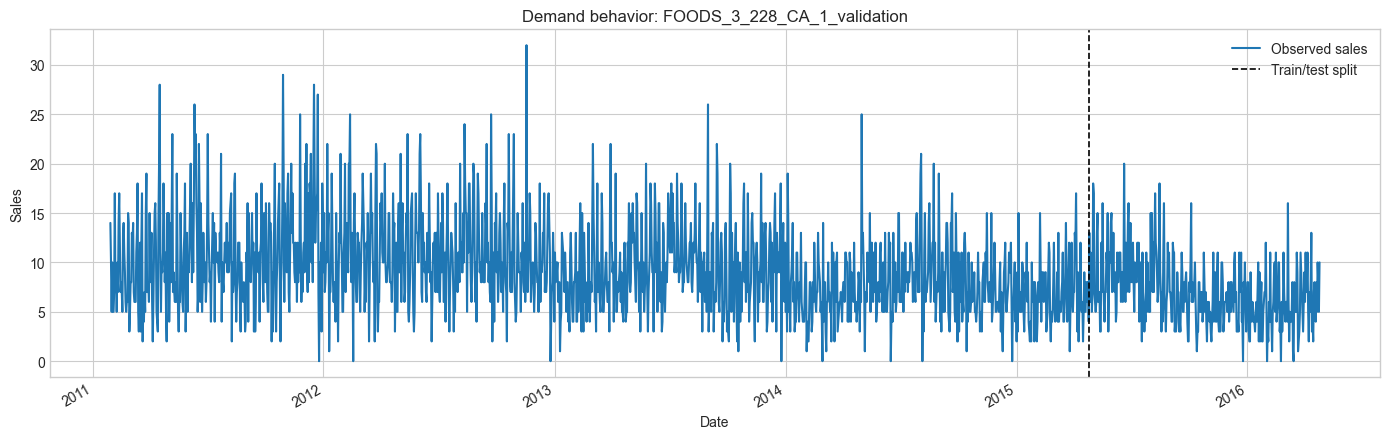

Saved: c:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\paper_experiments\30_m5_foods_3_228_ca_1_validation\product_behavior.png


In [4]:
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(df['date'], df['sales'], linewidth=1.5, label='Observed sales')
ax.axvline(train_df['date'].max(), color='black', linestyle='--', linewidth=1.2, label='Train/test split')
ax.set_title(f"Demand behavior: {CONFIG['SERIES_ID']}")
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
behavior_plot_path = CONFIG['OUTPUT_DIR'] / 'product_behavior.png'
fig.savefig(behavior_plot_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {behavior_plot_path}')

In [5]:
model = LSTMForecastModel(
    context_length=CONFIG['CONTEXT_LENGTH'],
    hidden_size=CONFIG['HIDDEN_SIZE'],
    num_layers=CONFIG['NUM_LAYERS'],
    dropout=CONFIG['DROPOUT'],
    epochs=CONFIG['EPOCHS'],
    lr=CONFIG['LR'],
    seed=CONFIG['SEED'],
)

model.fit(y_train)
y_pred, conf_low, conf_up = model.forecast(len(y_test), y_train)
print('Training history:', model.training_history_)

Training history: {'final_loss': 0.1604033097003897}


In [6]:
beh = behavioral_metrics(y_test, y_pred)
variance_ratio = float(beh['variance_ratio'])
flat_prediction_flag = bool(variance_ratio < CONFIG['FLAT_VARIANCE_RATIO_THRESHOLD'])

results = pd.DataFrame([
    {
        'series_id': CONFIG['SERIES_ID'],
        'series_alias': CONFIG['SERIES_ALIAS'],
        'model': 'LSTMForecastModel',
        'test_days': CONFIG['TEST_DAYS'],
        'context_length': CONFIG['CONTEXT_LENGTH'],
        'epochs': CONFIG['EPOCHS'],
        'hidden_size': CONFIG['HIDDEN_SIZE'],
        'num_layers': CONFIG['NUM_LAYERS'],
        'final_loss': float(model.training_history_.get('final_loss', np.nan)),
        'mae': float(np.mean(np.abs(y_test - y_pred))),
        'rmse': float(np.sqrt(np.mean((y_test - y_pred) ** 2))),
        'pred_std': float(np.std(y_pred)),
        'real_std': float(np.std(y_test)),
        'variance_ratio': variance_ratio,
        'trend_correlation': float(beh['trend_correlation']),
        'direction_accuracy': float(beh['direction_accuracy']),
        'shape_similarity': float(beh['shape_similarity']),
        'peak_detection_rate': float(beh['peak_detection_rate']),
        'n_peaks_real': int(beh['n_peaks_real']),
        'n_peaks_detected': int(beh['n_peaks_detected']),
        'flat_prediction_flag': flat_prediction_flag,
    }
])

display(results.T.rename(columns={0: 'value'}))

,value
series_id,FOODS_3_228_CA_1_validation
series_alias,FOODS_3_228_CA_1_val
model,LSTMForecastModel
test_days,365
context_length,28
epochs,30
hidden_size,64
num_layers,2
final_loss,0.160403
mae,3.107237


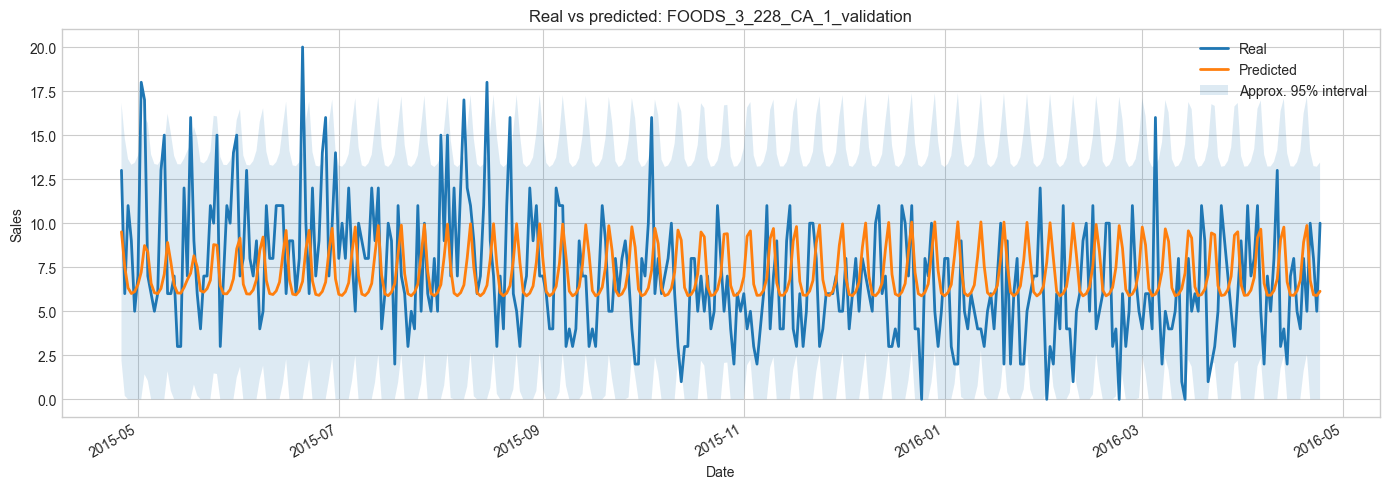

Saved: c:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\paper_experiments\30_m5_foods_3_228_ca_1_validation\real_vs_predicted.png


In [7]:
plot_df = test_df[['date', 'sales']].copy()
plot_df['y_pred'] = y_pred
plot_df['conf_low'] = conf_low
plot_df['conf_up'] = conf_up

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_df['date'], plot_df['sales'], label='Real', linewidth=2)
ax.plot(plot_df['date'], plot_df['y_pred'], label='Predicted', linewidth=2)
ax.fill_between(plot_df['date'], plot_df['conf_low'], plot_df['conf_up'], alpha=0.15, label='Approx. 95% interval')
ax.set_title(f"Real vs predicted: {CONFIG['SERIES_ID']}")
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
forecast_plot_path = CONFIG['OUTPUT_DIR'] / 'real_vs_predicted.png'
fig.savefig(forecast_plot_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {forecast_plot_path}')

In [ ]:
summary_path = CONFIG['OUTPUT_DIR'] / 'product_summary.csv'
metrics_path = CONFIG['OUTPUT_DIR'] / 'metrics.csv'
predictions_path = CONFIG['OUTPUT_DIR'] / 'predictions.csv'

summary.to_frame('value').to_csv(summary_path)
results.to_csv(metrics_path, index=False)
plot_df.to_csv(predictions_path, index=False)

print(f'Saved: {summary_path}')
print(f'Saved: {metrics_path}')
print(f'Saved: {predictions_path}')

## ACCESS Template Note

The folder `ACCESS_latex_template_20240429` is a manuscript template, not notebook execution code. In this adaptation, it is used as the target reporting format rather than as a runtime dependency.

Practical workflow:
1. Run this notebook.
2. Export `product_behavior.png`, `real_vs_predicted.png`, `product_summary.csv`, and `metrics.csv`.
3. Insert those artifacts into `ACCESS_latex_template_20240429/access.tex`.
4. Write the paper sections around the generated tables and figures.